# A daily newsvendor: choose the quantity from economics

A kiosk buys sandwiches once before a selling day. Unsold sandwiches have an end-of-day salvage value; unmet demand is lost. **How many should it buy today?**

This tutorial uses artificial historical daily demand as a simple predictive distribution. Unit economics selects the forecast quantile, `SingleOrderPolicy` makes one pre-demand purchase, and the validated event row explains the held-out outcome.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stockcast import InventoryStateDataFrame, SingleOrderPolicy, SimulationEngine, newsvendor_critical_fractile
from stockcast.evaluation import validate_event_frame


## 1. Forecast one selling day

The 60 historical observations are uncensored demand, not sales capped by stock. The declared artificial generator is stationary Poisson daily demand with mean 40; the forecaster is **not** given that mean. It uses an empirical predictive distribution that gives each historical day equal weight. This is a transparent baseline for comparable days, not a claim that real kiosk demand has no weekday or seasonal effects.

In [2]:
seed = 42
rng = np.random.default_rng(seed)
series = pd.DataFrame({
    'date': pd.date_range('2026-03-01', periods=61, freq='D'),
    'demand': rng.poisson(lam=40, size=61),
})
history = series.iloc[:-1].copy()
held_out = series.iloc[-1:].copy()
origin = history.date.iloc[-1]
selling_date = held_out.date.iloc[0]
forecast_samples = history.demand.to_numpy(copy=True)
assert origin + pd.Timedelta(days=1) == selling_date
print('History ends:', origin.date(), '| selling day:', selling_date.date())
print(history.tail(5).to_string(index=False))


History ends: 2026-04-29 | selling day: 2026-04-30
      date  demand
2026-04-25      42
2026-04-26      56
2026-04-27      46
2026-04-28      40
2026-04-29      52


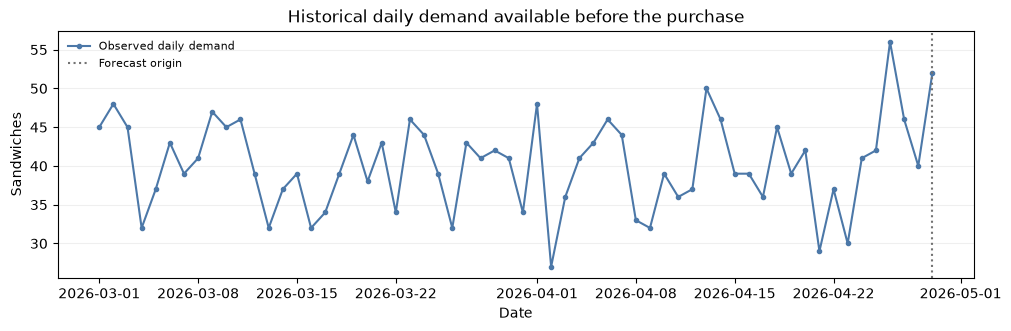

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.2), layout='constrained')
ax.plot(history.date, history.demand, marker='.', color='#4C78A8', label='Observed daily demand')
ax.axvline(origin, color='0.45', linestyle=':', label='Forecast origin')
ax.set(title='Historical daily demand available before the purchase', ylabel='Sandwiches', xlabel='Date')
ax.legend(frameon=False, fontsize=8)
ax.grid(axis='y', alpha=.2)
plt.show()


## 2. Let price, cost, and salvage select the quantile

A sandwich sells for **10**, costs **4** to buy, and can be salvaged for **2** if unsold. There is no opening stock, backlog, capacity limit, additional holding or shortage cost, or second purchase today. Under these linear lost-sales assumptions, underage costs `10 − 4 = 6` and overage costs `4 − 2 = 2`; the critical probability is `6 / (6 + 2) = 0.75`.

For whole sandwiches we choose the smallest historical-demand value whose empirical CDF reaches 0.75. We also calculate expected profit over candidate quantities using the **forecast samples only**, before revealing the held-out day.

In [4]:
price, cost, salvage = 10.0, 4.0, 2.0
alpha = newsvendor_critical_fractile(
    selling_price=price, purchase_cost=cost, salvage_value=salvage,
)
quantity = int(np.quantile(forecast_samples, alpha, method='inverted_cdf'))
candidates = np.arange(int(forecast_samples.max()) + 11)
scenario_profit = (
    price * np.minimum(candidates[:, None], forecast_samples)
    - cost * candidates[:, None]
    + salvage * np.maximum(candidates[:, None] - forecast_samples, 0)
)
expected_profit = scenario_profit.mean(axis=1)
assert np.isclose(expected_profit[quantity], expected_profit.max())
assert (forecast_samples < quantity).mean() < alpha <= (forecast_samples <= quantity).mean()
print(pd.DataFrame([{
    'critical_probability': alpha, 'empirical_forecast_mean': forecast_samples.mean(),
    'purchase_target': quantity, 'forecast_expected_profit': expected_profit[quantity],
}]).round(2).to_string(index=False))


 critical_probability  empirical_forecast_mean  purchase_target  forecast_expected_profit
                 0.75                     40.2               44                     226.8


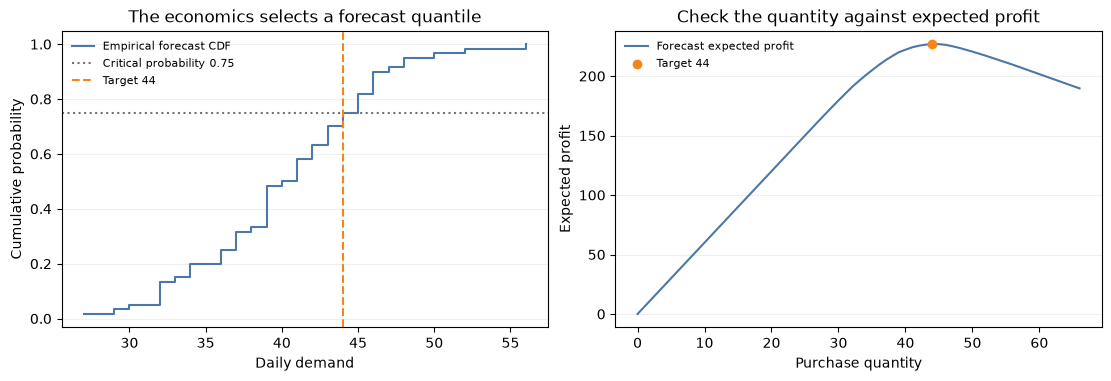

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.7), layout='constrained')
values, counts = np.unique(forecast_samples, return_counts=True)
axes[0].step(values, counts.cumsum() / len(forecast_samples), where='post', color='#4C78A8', label='Empirical forecast CDF')
axes[0].axhline(alpha, color='0.45', linestyle=':', label=f'Critical probability {alpha:.2f}')
axes[0].axvline(quantity, color='#F58518', linestyle='--', label=f'Target {quantity}')
axes[0].set(title='The economics selects a forecast quantile', xlabel='Daily demand', ylabel='Cumulative probability')
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(candidates, expected_profit, color='#4C78A8', label='Forecast expected profit')
axes[1].scatter([quantity], [expected_profit[quantity]], color='#F58518', zorder=3, label=f'Target {quantity}')
axes[1].set(title='Check the quantity against expected profit', xlabel='Purchase quantity', ylabel='Expected profit')
axes[1].legend(frameon=False, fontsize=8)
for ax in axes: ax.grid(axis='y', alpha=.2)
plt.show()


## 3. Make the one-day purchase

The empirical forecaster has finished its work. We hand Stockcast the selected quantity with the probability, information origin, daily frequency, one-day end date, and external source. `SingleOrderPolicy` has one decision opportunity; with zero lead time its accepted order arrives before demand on the selling day. No salvage transaction is performed by the engine.

In [6]:
sku = 'sandwich'
target = pd.DataFrame({'unique_id': [sku], 'target': [quantity], 'target_end': [selling_date]})
policy = SingleOrderPolicy(
    lead_time=0, selling_horizon=1, service_level=alpha, allow_backorders=False,
).fit(
    target, forecast_origin=origin, forecast_frequency='D',
    target_column='target', target_probability=alpha,
    target_end_date_column='target_end', target_source='external_direct',
)
opening = InventoryStateDataFrame([sku], max_lead_time=0, allow_backorders=False).initialize_zero(start_date=origin)
print(target.to_string(index=False))
print(pd.DataFrame([policy.get_target_metadata()]).to_string(index=False))


unique_id  target target_end
 sandwich      44 2026-04-30
      representation  target_probability  protection_horizon   target_source     forecast_origin forecast_frequency     target_end_date coverage_start_date  selling_horizon
single_season_target                0.75                   1 external_direct 2026-04-29T00:00:00                  D 2026-04-30T00:00:00 2026-04-30T00:00:00                1


## 4. Reveal the held-out day and account for it

The held-out demand is used only now. Stockcast records the purchase, immediate receipt, sales, lost sales, and leftover stock. We compute revenue and terminal salvage explicitly from that validated event; leftover stock is still present in the returned inventory state.

In [7]:
actual = int(held_out.demand.iloc[0])
demand = pd.DataFrame({'unique_id': [sku], 'period': [0], 'date': [selling_date], 'y': [actual]})
result = SimulationEngine().run(
    policy, demand, opening, n_periods=1, period_frequency='D',
    warmup_periods=0, scoring_periods=1, settlement_periods=0,
    order_during_settlement=False, demand_source_name='synthetic_heldout_selling_day',
    random_seed=seed,
)
events = validate_event_frame(result.to_event_frame())
row = events.iloc[0]
realized_profit = price * row.fulfilled_units - cost * row.order_quantity + salvage * row.ending_on_hand
assert events.order_event_count.sum() == 1
assert row.order_quantity == row.received_units == quantity
assert row.fulfilled_units == min(quantity, actual)
assert row.ending_on_hand == max(quantity - actual, 0)
assert row.lost_sales_units == max(actual - quantity, 0)
assert row.on_order_end == 0
print(pd.DataFrame([{
    'target': quantity, 'demand': actual, 'ordered': row.order_quantity,
    'received': row.received_units, 'sold': row.fulfilled_units,
    'lost_sales': row.lost_sales_units, 'leftover': row.ending_on_hand,
    'revenue': price * row.fulfilled_units, 'purchase_cost': cost * row.order_quantity,
    'salvage_value': salvage * row.ending_on_hand, 'realized_profit': realized_profit,
}]).round(2).to_string(index=False))


 target  demand  ordered  received  sold  lost_sales  leftover  revenue  purchase_cost  salvage_value  realized_profit
     44      39     44.0      44.0  39.0         0.0       5.0    390.0          176.0           10.0            224.0


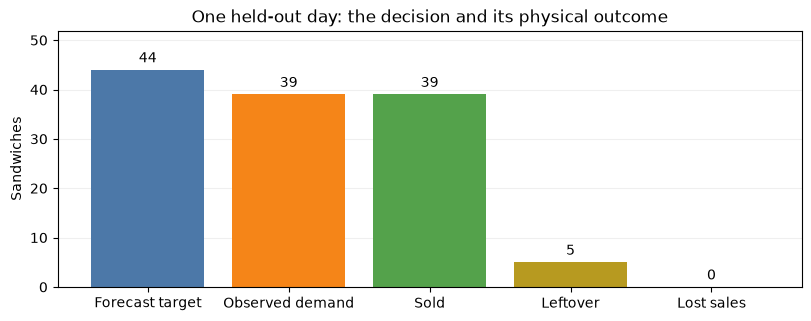

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.1), layout='constrained')
labels = ['Forecast target', 'Observed demand', 'Sold', 'Leftover', 'Lost sales']
values = [quantity, actual, row.fulfilled_units, row.ending_on_hand, row.lost_sales_units]
bars = ax.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B', '#B79A20', '#E45756'])
ax.bar_label(bars, fmt='%.0f', padding=3)
ax.set(title='One held-out day: the decision and its physical outcome', ylabel='Sandwiches')
ax.set_ylim(0, max(values) * 1.18)
ax.grid(axis='y', alpha=.2)
ax.set_axisbelow(True)
plt.show()


## What this establishes

The price–cost–salvage rule selected a probability; the historical demand distribution supplied its quantity; Stockcast made and accounted for one purchase. The expected-profit check is true **under that empirical forecast**, and the event row verifies the one realized day. Neither result establishes that the forecast is calibrated or that this quantity is best for a real kiosk.

The next three notebooks extend the forecast target over multiple demand periods, then update and compare those cumulative targets.